# Active learning experiment setup

**Purpose**: Minimal end-to-end example: configure dataset+model, initialize the ActiveLearningSystem, train for a few epochs, query new samples, and visualize them.

## Prerequisites
- Datasets available locally (update `data_dir`).
- The repo modules `config.config` and `src.active_learning` are importable from `PROJECT_ROOT`.

## How to run
- Update dataset/model fields in the config cell.
- Run initialization, training, and query cells.
- Optional: visualize a few queried samples.

## Notes
- Paths in this notebook are repository- and machine-specific; update them before running.
- If you're running from the `notebooks/` folder, the `PROJECT_ROOT` logic should work as-is.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
from config.config import ActiveLearningConfig
print(f'ActiveLearningConfig is imported')
from src.active_learning import ActiveLearningSystem

PROJECT_ROOT: /home3/vzcl68/Code/Active_Learning_Benchmarking
ActiveLearningConfig is imported
Data modules package initialized.


In [2]:
config = ActiveLearningConfig()

# ---- dataset ----
config.dataset_type = "deepcrack"   # or deepcrack
config.data_dir = "/home3/vzcl68/Datasets/DeepCrack/"
config.img_size = 256
# ---- model ----
config.task = 'segmentation'
config.model_type = "unet"                  # or "maskrcnn"
config.num_classes = 2

# ---- active learning ----
config.cold_start_strategy = "random"
config.query_strategy = "uncertainty"
config.query_size = 10
config.initial_labeled_size = 20

# ---- training ----
config.epochs = 3
config.batch_size = 4
config.num_workers = 2
config.lr = 1e-3
config.weight_decay = 1e-4


# ---- logging ----
config.use_wandb = False

### Configuration guide
- **dataset_type / data_dir / img_size**: select dataset loader and path.
- **task / model_type / num_classes**: choose segmentation vs detection and the model wrapper.
- **cold_start_strategy**: how the initial labeled pool is selected (e.g., random/diversity).
- **query_strategy**: how new samples are selected each AL cycle (e.g., uncertainty/diversity).
- **initial_labeled_size / query_size**: dataset budget per iteration.

If your `ActiveLearningConfig` includes training fields (epochs, lr, batch size, etc.), set them here as well.

In [3]:
al_system = ActiveLearningSystem(config)

print("Initial labeled set:", len(al_system.labeled_indices))
print("Initial unlabeled pool:", len(al_system.unlabeled_indices))

[DeepCrack] 300 samples loaded for split='train'
[DeepCrack] 237 samples loaded for split='val'


2026-01-30 11:57:21,809 - experiment_1 - INFO - Initialized with 30 labeled and 270 unlabeled samples


Applying cold start strategy: random
Active Learning System initialized with:
  Device: cuda
  Cold Start Strategy: random
  Query Strategy: uncertainty
  Initial labeled: 30 samples
Initial labeled set: 30
Initial unlabeled pool: 270


## Initial training
- Runs a short training to make sure the pipeline works end-to-end.
- For quick debugging, keep epochs small (e.g., 1–3).


In [4]:
print("🚀 Initial training")
metrics = al_system.train(epochs=3)

🚀 Initial training

Training cycle 0 with 30 samples
Epoch 1:
  Training time: 18.3s
  AP@[IoU=0.50:0.95]: 0.0000
Epoch 2:
  Training time: 6.0s
  AP@[IoU=0.50:0.95]: 0.0000
Epoch 3:
  Training time: 6.0s
  AP@[IoU=0.50:0.95]: 0.0000


## Query new samples
- Selects `query_size` samples from the unlabeled pool using the configured strategy.
- Returned indices are added to `labeled_indices`.


In [5]:
print("🔍 Querying new samples")
new_samples = al_system.query(query_size=10)

print("Newly selected samples:", len(new_samples))
print("Now labeled:", len(al_system.labeled_indices))
print("Now unlabeled:", len(al_system.unlabeled_indices))

🔍 Querying new samples


2026-01-30 11:58:43,876 - experiment_1 - INFO - Selected 10 new samples. Now 40 labeled, 260 unlabeled


Newly selected samples: 10
Now labeled: 40
Now unlabeled: 260


## Visualize queried samples
- Quick qualitative check that the selected images look reasonable.
- If using segmentation/detection, you may also want to render masks/boxes here.


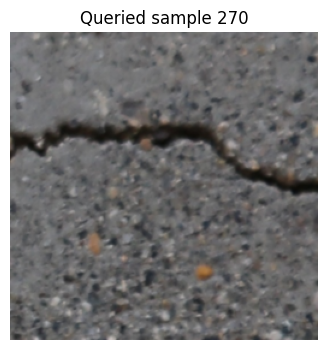

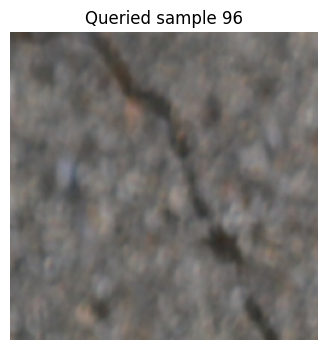

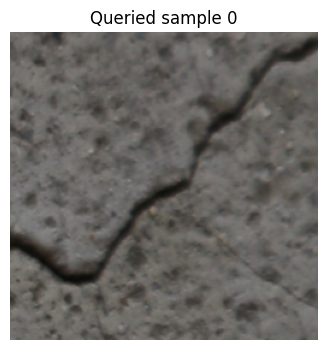

In [6]:
import matplotlib.pyplot as plt

for idx in new_samples[:3]:
    img, target = al_system.dataset_train[idx]

    plt.figure(figsize=(4,4))
    plt.imshow(img.permute(1,2,0))
    plt.title(f"Queried sample {idx}")
    plt.axis("off")
    plt.show()

## Next steps
- Wrap the train→query loop into multiple AL cycles and log metrics per cycle.
- Save results to a JSON/CSV so `06_result_analysis.ipynb` can consume them.
